# Few-Shot Experiment on SHD: HH-PC vs LIF-PC

Same few-shot protocol as the MNIST/FMNIST notebook, ported to **SHD**
(Spiking Heidelberg Digits, 20 classes, 700 cochlea channels).

- **k-shot grid**: `k ∈ {1, 5, 10, 20}` samples *per class* → 20 / 100 / 200 /
  400 training samples total, plus an optional full-data reference row.
- **2 neuron models**: HH (`HHNeuron` from `hhpc_base.py`) and LIF, sharing
  identical PC inference / PC learning / metrics code.
- **`N_REPEATS` seeds per cell**, reported as mean ± std. Few-shot results at
  k=1 are extremely seed-sensitive; a single draw is not a result.
- **Logistic-regression baseline** on the same k-shot subsets, so the numbers
  have a reference point rather than only comparing HH against LIF.

SHD-specific settings carried over from the main SHD run:

| setting | value | why |
|---|---|---|
| `TBINS × CH` | 50 × 140 | input binning, independent of `steps_spk` |
| `tau_ref` | 0.15 (5 steps) | default 2.0 = 67 steps > `steps_spk` |
| `I_bias` | `[1.5, 3.0]` | per-layer; output needs more drive at C=20 |
| PC targets | soft (0.9 / 0.005) | hard one-hot freezes output rows at C=20 |
| val split | speaker-level | file-level split leaks speakers |
| augmentation | on | matters far more at k=1 than at full data |

**Compute:** 4 k-values × 2 neuron types × `N_REPEATS` seeds = 24 runs at the
default `N_REPEATS=3`, each on ≤400 samples, so the whole grid is fast. The
driver is resumable from `RESULTS_CSV`.


## 0. Setup

In [1]:
import os, sys, glob, gzip, shutil, time, json, csv, math, types, random, urllib.request
from dataclasses import dataclass, asdict
from typing import List, Optional, Dict, Any, Tuple

import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset, Subset
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

_hits = (glob.glob('/kaggle/input/**/hhpc_base.py', recursive=True) +
         glob.glob('/kaggle/working/**/hhpc_base.py', recursive=True) +
         glob.glob('./hhpc_base.py'))
assert _hits, 'hhpc_base.py not found — attach the dataset'
sys.path.insert(0, os.path.dirname(os.path.abspath(_hits[0])))
from hhpc_base import (PCSNNet, HHNeuron, MetricAccumulator,
                       one_hot, set_seed, default_device)

print('hhpc_base at:', _hits[0])
print('Torch:', torch.__version__, '| CUDA:', torch.cuda.is_available())


hhpc_base at: /kaggle/input/datasets/ishraqkamaladib/hhpc-base/hhpc_base.py
Torch: 2.10.0+cu128 | CUDA: True


In [2]:
# ── SHD constants ─────────────────────────────────────────────────────────
DATA_DIR = '/kaggle/working/shd'
CKPT_DIR = '/kaggle/working/ckpts_shd_fewshot'
OUT_DIR  = '/kaggle/working'

N_CH, POOL, TBINS, T_MAX = 700, 5, 50, 1.0
NUM_CLASSES = 20
CH   = N_CH // POOL          # 140
D_IN = TBINS * CH            # 7000

DT           = 0.03
TAU_REF      = 0.15
I_BIAS       = [1.5, 3.0]    # [hidden, output]
CURRENT_GAIN = 30.0
THR          = 0.8           # HH
LIF_THR      = 1.0           # LIF (different voltage scale)
LIF_TAU      = 0.3
TGT_HI, TGT_LO = 0.9, 0.1
TIME_SHIFT_MAX, CH_DROP_P = 4, 0.15
N_VAL_SPK    = 2
SEED         = 123

DEVICE = default_device()
set_seed(SEED)
os.makedirs(DATA_DIR, exist_ok=True); os.makedirs(CKPT_DIR, exist_ok=True)
torch.backends.cudnn.benchmark = True
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
print('device:', DEVICE, '| D_in:', D_IN, '| classes:', NUM_CLASSES)


device: cuda | D_in: 7000 | classes: 20


## 1. Data

In [3]:
# ── locate or download shd_train.h5 / shd_test.h5 ─────────────────────────
try:
    import h5py
except ImportError:
    os.system('pip install -q h5py'); import h5py

URLS = {'train': 'https://zenkelab.org/datasets/shd_train.h5.gz',
        'test':  'https://zenkelab.org/datasets/shd_test.h5.gz'}

def get_h5(split):
    for pat in (f'/kaggle/input/**/shd_{split}.h5', f'{DATA_DIR}/shd_{split}.h5',
                f'/kaggle/input/**/shd_{split}.h5.gz'):
        hits = glob.glob(pat, recursive=True)
        if hits:
            p = hits[0]
            if p.endswith('.gz'):
                out = f'{DATA_DIR}/shd_{split}.h5'
                if not os.path.exists(out):
                    with gzip.open(p, 'rb') as fi, open(out, 'wb') as fo:
                        shutil.copyfileobj(fi, fo)
                return out
            return p
    gz, out = f'{DATA_DIR}/shd_{split}.h5.gz', f'{DATA_DIR}/shd_{split}.h5'
    print(f'downloading {split} ...', flush=True)
    urllib.request.urlretrieve(URLS[split], gz)
    with gzip.open(gz, 'rb') as fi, open(out, 'wb') as fo:
        shutil.copyfileobj(fi, fo)
    return out

H5_TRAIN, H5_TEST = get_h5('train'), get_h5('test')
print('ok:', H5_TRAIN, H5_TEST)


downloading train ...
downloading test ...
ok: /kaggle/working/shd/shd_train.h5 /kaggle/working/shd/shd_test.h5


In [4]:
# ── bin (times, units) -> TBINS x CH frame ────────────────────────────────
def load_shd(path, tbins=TBINS, pool=POOL, n_ch=N_CH, t_max=T_MAX):
    ch = n_ch // pool
    with h5py.File(path, 'r') as f:
        times, units = f['spikes']['times'], f['spikes']['units']
        labels = np.asarray(f['labels'], np.int64)
        spk = (np.asarray(f['extra']['speaker'], np.int64)
               if 'extra' in f and 'speaker' in f['extra'] else np.zeros(len(labels), np.int64))
        X = np.zeros((len(labels), tbins * ch), np.float32)
        for i in range(len(labels)):
            t = np.asarray(times[i], np.float64); u = np.asarray(units[i], np.int64)
            if t.size == 0:
                continue
            ti = np.clip((t / t_max * tbins).astype(np.int64), 0, tbins - 1)
            ui = np.clip(u // pool, 0, ch - 1)
            cnt = np.log1p(np.bincount(ti * ch + ui, minlength=tbins * ch).astype(np.float32))
            m = cnt.max(); X[i] = cnt / m if m > 0 else cnt
    return X, labels, spk

t0 = time.time()
Xtr_all, ytr_all, spk_tr = load_shd(H5_TRAIN)
Xte,     yte,     spk_te = load_shd(H5_TEST)
print(f'loaded in {time.time()-t0:.1f}s | train {Xtr_all.shape} test {Xte.shape}')


loaded in 5.9s | train (8156, 7000) test (2264, 7000)


## 2. Few-shot sampler

The split is built in two stages so the few-shot claim is clean:

1. **Speaker-level val split first.** Two speakers are held out entirely for
   validation. Few-shot sampling then draws only from the remaining speakers,
   so the k support samples can never share a speaker with the val set.
2. **k per class** drawn from that pool, with a per-repeat seed. Test is always
   the full official SHD test set (disjoint speakers), never subsampled — so
   accuracy across k values is measured on the same fixed test distribution.

In [5]:
# ── speaker-level val split ───────────────────────────────────────────────
rng = np.random.RandomState(SEED)
spk_ids = np.unique(spk_tr)
val_spk = rng.choice(spk_ids, size=min(N_VAL_SPK, len(spk_ids)), replace=False)
val_mask = np.isin(spk_tr, val_spk)
POOL_IDX, VAL_IDX = np.where(~val_mask)[0], np.where(val_mask)[0]
print('held-out val speakers:', val_spk, '| pool n =', len(POOL_IDX),
      '| val n =', len(VAL_IDX))

per_class_min = min(int((ytr_all[POOL_IDX] == c).sum()) for c in range(NUM_CLASSES))
print('min samples per class in the few-shot pool:', per_class_min)


def few_shot_indices(k_shot, seed=42, num_classes=NUM_CLASSES):
    """Exactly k_shot indices per class, drawn from the non-val speaker pool."""
    if k_shot is None:
        return POOL_IDX.copy()
    r = random.Random(seed)
    labels = ytr_all[POOL_IDX]
    sel = []
    for c in range(num_classes):
        pool = POOL_IDX[labels == c].tolist()
        if len(pool) < k_shot:
            raise ValueError(f'class {c} has only {len(pool)} samples; k_shot={k_shot}')
        r.shuffle(pool)
        sel.extend(pool[:k_shot])
    r.shuffle(sel)
    return np.asarray(sel, dtype=np.int64)


class AugmentedSHD(Dataset):
    """Random circular time shift + pooled-channel dropout, per __getitem__."""
    def __init__(self, X, y, tbins=TBINS, ch=CH, max_shift=TIME_SHIFT_MAX, drop_p=CH_DROP_P):
        self.X, self.y, self.tbins, self.ch = X, y, tbins, ch
        self.max_shift, self.drop_p = max_shift, drop_p
    def __len__(self):  return len(self.y)
    def __getitem__(self, i):
        x = self.X[i].reshape(self.tbins, self.ch)
        s = np.random.randint(-self.max_shift, self.max_shift + 1)
        if s: x = np.roll(x, s, axis=0)
        if self.drop_p > 0:
            x = x * (np.random.rand(self.ch) >= self.drop_p)[None, :]
        return torch.from_numpy(np.ascontiguousarray(x.reshape(-1))), int(self.y[i])


def to_ds(X, y, idx=None):
    if idx is not None: X, y = X[idx], y[idx]
    return TensorDataset(torch.from_numpy(X), torch.from_numpy(y))

_KW = dict(num_workers=0, pin_memory=DEVICE.startswith('cuda'))

def make_fewshot_loaders(k_shot, batch_size=32, seed=42, augment=True):
    idx = few_shot_indices(k_shot, seed=seed)
    tr_ds = (AugmentedSHD(Xtr_all[idx], ytr_all[idx]) if augment
             else to_ds(Xtr_all, ytr_all, idx))
    return (DataLoader(tr_ds, batch_size, shuffle=True, drop_last=False, **_KW),
            DataLoader(to_ds(Xtr_all, ytr_all, VAL_IDX), 128, shuffle=False, **_KW),
            DataLoader(to_ds(Xte, yte), 128, shuffle=False, **_KW),
            idx)

_tr, _va, _te, _idx = make_fewshot_loaders(5, seed=0)
print('k=5 ->', len(_idx), 'train |', len(_va.dataset), 'val |', len(_te.dataset), 'test')


held-out val speakers: [6 0] | pool n = 6796 | val n = 1360
min samples per class in the few-shot pool: 322
k=5 -> 100 train | 1360 val | 2264 test


## 3. LIF neuron

In [6]:
class LIFNeuron(nn.Module):
    """Matches HHNeuron's forward(I) -> (spk, V) / reset_states(B) interface,
    so PCSNNet can swap between the two with a single flag. `tau` is the
    membrane time constant (dV = (-V + I) * dt/tau), LIF-specific."""
    def __init__(self, N, dt=DT, device='cpu', thr=LIF_THR, reset=0.0,
                 tau=LIF_TAU, tau_ref=TAU_REF):
        super().__init__()
        self.N, self.dt, self.device = N, float(dt), device
        self.thr, self.reset, self.tau = float(thr), float(reset), float(tau)
        self.tau_ref = float(tau_ref)
        self.reset_states(1)

    def reset_states(self, B: int):
        self.B = B
        self.Vm   = torch.zeros(B, self.N, device=self.device)
        self.refr = torch.zeros(B, self.N, device=self.device)
        self.refr_steps = max(1, int(round(self.tau_ref / self.dt)))

    def forward(self, I: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        if I.shape[0] != getattr(self, 'B', None):
            self.reset_states(I.shape[0])
        can = (self.refr <= 0)
        Vn  = self.Vm + (-self.Vm + I) * (self.dt / max(self.tau, 1e-6))
        spk = ((Vn >= self.thr) & can).float()
        self.Vm = torch.where(spk.bool(), torch.full_like(Vn, self.reset), Vn)
        self.refr = torch.where(spk.bool(),
                                torch.full_like(self.refr, float(self.refr_steps)),
                                torch.clamp(self.refr - 1.0, min=0.0))
        return spk, self.Vm


## 4. Model builder

`PCSNNet` from the base file is reused unchanged for PC inference, PC learning
and the optimiser. Patched on top: cells swapped for LIF when requested, HH's
refractory window corrected to `tau_ref=0.15`, and `forward_proxies` replaced
with a per-layer-`I_bias` version.

In [7]:
def _forward_proxies(self, x_in, steps_spk):
    """Poisson-encode the binned SHD frame, simulate steps_spk steps with
    per-layer I_bias. Signature-compatible with PCSNNet.forward_proxies."""
    x0 = x_in.to(self.device).clamp(0, 1)
    B = x0.size(0)
    for cell in self.cells:
        cell.reset_states(B)

    p = (x0 * self.poisson_scale).clamp(0, 1)
    spk_train = (torch.rand(B, x0.size(1), steps_spk, device=self.device)
                 < p.unsqueeze(-1)).float()

    spike_sums = [torch.zeros(B, self.sizes[i+1], device=self.device) for i in range(self.S)]
    for t in range(steps_spk):
        r = spk_train[:, :, t]
        for i in range(self.S):
            I = F.linear(r, self.syn[i].weight, self.syn[i].bias) * self.current_gain \
                + self.I_bias_list[i]
            spk, _ = self.cells[i](I)
            spike_sums[i] += spk
            r = spk

    self._last_spike_sums = spike_sums
    return [x0] + [(ss / float(steps_spk)).clamp(0, 1) for ss in spike_sums]


def build_model(neuron_type='hh', hidden=256, lr=2e-4, weight_decay=1e-4,
                i_bias=None, seed=SEED):
    set_seed(seed)                       # identical init for HH and LIF at a seed
    m = PCSNNet(layer_sizes=[D_IN, hidden, NUM_CLASSES], dt=DT, device=DEVICE,
                current_gain=CURRENT_GAIN, thr=THR, lr=lr, weight_decay=weight_decay,
                pc_activation='relu', input_encoding='poisson').to(DEVICE)
    m.neuron_type = neuron_type
    m.I_bias_list = list(i_bias if i_bias is not None else I_BIAS)

    if neuron_type == 'lif':
        m.cells = nn.ModuleList([
            LIFNeuron(m.sizes[i+1], dt=DT, device=DEVICE, thr=LIF_THR,
                      tau=LIF_TAU, tau_ref=TAU_REF)
            for i in range(m.S)]).to(DEVICE)
    else:
        for c in m.cells:
            c.refr_steps = max(1, int(round(TAU_REF / DT)))

    m.forward_proxies = types.MethodType(_forward_proxies, m)
    return m


# ── soft PC targets (hard one-hot freezes output rows at C=20) ────────────
def soft_one_hot(y, C, hi=TGT_HI, lo=TGT_LO):
    t = torch.full((y.size(0), C), lo / C, device=y.device)
    t.scatter_(1, y.view(-1, 1).long(), hi)
    return t

def make_target(y, C):
    return soft_one_hot(y, C)


## 5. Evaluation helpers

In [8]:
def _fork_devs():
    return ([torch.cuda.current_device()]
            if str(DEVICE).startswith('cuda') and torch.cuda.is_available() else [])


@torch.no_grad()
def spike_rate_epoch(model, loader, device, steps_spk, eval_seed=1234):
    model.eval()
    S = model.S
    tot_spk, tot_den, n = [0.] * S, [0.] * S, 0
    with torch.random.fork_rng(devices=_fork_devs(), enabled=True):
        torch.manual_seed(eval_seed)
        for x, _ in loader:
            x = x.to(device, non_blocking=True).view(x.size(0), -1); B = x.size(0)
            model.forward_proxies(x, steps_spk)
            ss = model.last_spike_sums()
            if ss is None: continue
            for li in range(S):
                tot_spk[li] += float(ss[li].sum())
                tot_den[li] += float(B * ss[li].shape[1] * steps_spk)
            n += B
    return {'per_layer': [tot_spk[i] / max(tot_den[i], 1.) for i in range(S)],
            'total': sum(tot_spk) / max(sum(tot_den), 1.),
            'spikes_per_sample': sum(tot_spk) / max(n, 1)}


@torch.no_grad()
def eval_epoch(model, loader, device, steps_spk, T_infer_eval, eta_x_eval,
               eval_mode='pc', eval_seed=1234):
    model.eval()
    C = model.sizes[-1]
    ff_accum, pc_accum = MetricAccumulator(C), MetricAccumulator(C)
    total_energy, total = 0.0, 0
    with torch.random.fork_rng(devices=_fork_devs(), enabled=True):
        torch.manual_seed(eval_seed)
        for x, y in loader:
            x = x.to(device, non_blocking=True).view(x.size(0), -1)
            y = y.to(device, non_blocking=True); B = x.size(0)
            proxies = model.forward_proxies(x, steps_spk)

            ff_pred = proxies[-1].argmax(dim=1)
            ff_accum.update(ff_pred.cpu(), y.cpu())

            if eval_mode == 'pc':
                xs, _, _, _ = model.pc_infer(proxies, None, T_infer_eval,
                                             eta_x_eval, False)
                pc_accum.update(xs[-1].argmax(dim=1).cpu(), y.cpu())
            else:
                pc_accum.update(ff_pred.cpu(), y.cpu())

            _, _, _, energy = model.pc_infer(proxies, one_hot(y, C), T_infer_eval,
                                             eta_x_eval, True)
            total_energy += float(energy) * B; total += B

    ff_m, pc_m = ff_accum.compute(), pc_accum.compute()
    return {'ff_acc': ff_m['acc'], 'ff_f1': ff_m['f1'],
            'mode_acc': pc_m['acc'], 'mode_f1': pc_m['f1'],
            'mode_precision': pc_m['precision'], 'mode_recall': pc_m['recall'],
            'pc_energy': total_energy / max(total, 1)}


def _pretty(m):
    return (f"acc={m['acc']:.3f} P={m['precision']:.3f} "
            f"R={m['recall']:.3f} F1={m['f1']:.3f}")


## 6. Configuration

In [9]:
@dataclass
class Cfg:
    # --- dataset ---
    dataset:     str = 'SHD'
    num_classes: int = NUM_CLASSES
    input_dim:   int = D_IN

    # --- network ---
    hidden_size: int = 256
    neuron_type: str = 'hh'          # 'hh' | 'lif'

    # --- spiking ---
    steps_spk: int = 50

    # --- PC / training ---
    lr:            float = 2e-4
    weight_decay:  float = 2e-4
    T_infer_train: int   = 100
    T_infer_eval:  int   = 50
    eta_x:         float = 0.05
    eval_mode:     str   = 'pc'

    # --- loop ---
    epochs:     int = 40
    batch_size: int = 32

    # --- few-shot ---
    k_shot:  Optional[int] = 5       # None = full pool
    augment: bool = True
    repeat:  int  = 0                # which seed draw

    eval_seed: int = 1234
    ckpt: str = 'best_model.pt'

    @property
    def layer_sizes(self):
        return (self.input_dim, self.hidden_size, self.num_classes)


## 7. Training loop

Two differences from the MNIST few-shot loop, both forced by C=20 SHD:
targets are **soft**, and the checkpoint monitor is **macro-F1** rather than
accuracy — at 20 classes a model can hold accuracy while silently losing
output classes, which is exactly the failure mode soft targets exist to fix.

In [10]:
def train_model(model, train_loader, val_loader, device, cfg: Cfg, verbose=True):
    hist = {'train_energy': [], 'train_mode': [], 'val_mode': [],
            'val_energy': [], 'val_spike_rate': [], 'epoch_time': []}
    os.makedirs(os.path.dirname(cfg.ckpt) or '.', exist_ok=True)
    best_f1 = -1.0

    if verbose:
        print(f'\n===== TRAINING: {cfg.neuron_type.upper()}-PC | SHD | '
              f'k={cfg.k_shot} | repeat={cfg.repeat} =====', flush=True)

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        t0 = time.time()
        energy_sum, total_seen = 0.0, 0
        tr_accum = MetricAccumulator(cfg.num_classes)

        pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{cfg.epochs}',
                    ncols=110, disable=not verbose, leave=False)
        for x, y in pbar:
            x = x.to(device, non_blocking=True).view(x.size(0), -1)
            y = y.to(device, non_blocking=True)

            energy, proxies = model.train_step(
                x, make_target(y, cfg.num_classes),
                steps_spk=cfg.steps_spk, T_infer=cfg.T_infer_train, eta_x=cfg.eta_x)
            B = x.size(0); total_seen += B; energy_sum += float(energy) * B

            if cfg.eval_mode == 'pc':
                xs, _, _, _ = model.pc_infer(proxies, None,
                                             max(1, cfg.T_infer_eval // 2),
                                             cfg.eta_x, False)
                pred = xs[-1].argmax(dim=1)
            else:
                pred = proxies[-1].argmax(dim=1)
            tr_accum.update(pred.detach().cpu(), y.detach().cpu())
            if verbose:
                pbar.set_postfix({'E': f'{float(energy):.4f}',
                                  'TrAcc': f"{tr_accum.compute()['acc']:.3f}"})

        epoch_time = time.time() - t0
        train_energy = energy_sum / max(total_seen, 1)
        train_m = tr_accum.compute()

        val_stats = eval_epoch(model, val_loader, device, cfg.steps_spk,
                               cfg.T_infer_eval, cfg.eta_x, cfg.eval_mode, cfg.eval_seed)
        val_rates = spike_rate_epoch(model, val_loader, device, cfg.steps_spk, cfg.eval_seed)

        val_m = {k: val_stats[f'mode_{k}'] for k in ('acc', 'precision', 'recall', 'f1')}
        hist['train_energy'].append(train_energy)
        hist['train_mode'].append(train_m)
        hist['val_mode'].append(val_m)
        hist['val_energy'].append(val_stats['pc_energy'])
        hist['val_spike_rate'].append(val_rates)
        hist['epoch_time'].append(epoch_time)

        if val_m['f1'] > best_f1:
            best_f1 = val_m['f1']
            torch.save(model.state_dict(), cfg.ckpt)
            star = '  [ckpt]'
        else:
            star = ''

        if verbose:
            print(f"  Ep{epoch:02d} | E={train_energy:.5f} | TR [{_pretty(train_m)}] "
                  f"| VAL [{_pretty(val_m)}] | t={epoch_time:.1f}s{star}", flush=True)

    if os.path.exists(cfg.ckpt):
        model.load_state_dict(torch.load(cfg.ckpt, map_location=device))
    return hist, best_f1


## 8. Single experiment runner

In [11]:
def run_experiment(cfg: Cfg, device: str, train_loader, val_loader, test_loader,
                   n_train: int, verbose=True) -> Dict[str, Any]:
    model = build_model(cfg.neuron_type, hidden=cfg.hidden_size,
                        lr=cfg.lr, weight_decay=cfg.weight_decay,
                        seed=SEED + cfg.repeat)

    hist, best_val_f1 = train_model(model, train_loader, val_loader, device, cfg, verbose)

    test_stats = eval_epoch(model, test_loader, device, cfg.steps_spk,
                            cfg.T_infer_eval, cfg.eta_x, cfg.eval_mode, cfg.eval_seed)
    test_rates = spike_rate_epoch(model, test_loader, device, cfg.steps_spk, cfg.eval_seed)

    result = {'dataset': 'SHD', 'neuron_type': cfg.neuron_type,
              'k_shot': -1 if cfg.k_shot is None else cfg.k_shot,
              'repeat': cfg.repeat, 'n_train': n_train,
              'test_acc': test_stats['mode_acc'], 'test_f1': test_stats['mode_f1'],
              'test_precision': test_stats['mode_precision'],
              'test_recall': test_stats['mode_recall'],
              'test_ff_acc': test_stats['ff_acc'], 'test_ff_f1': test_stats['ff_f1'],
              'test_energy': test_stats['pc_energy'],
              'spike_rate': test_rates['total'],
              'spikes_per_sample': test_rates['spikes_per_sample'],
              'best_val_f1': best_val_f1,
              'val_accs': [m['acc'] for m in hist['val_mode']],
              'val_f1s':  [m['f1']  for m in hist['val_mode']],
              'train_energies': hist['train_energy']}

    if verbose:
        print(f"\n  *** TEST  Acc={result['test_acc']:.4f}  F1={result['test_f1']:.4f}  "
              f"Energy={result['test_energy']:.5f}  "
              f"SpikeRate={result['spike_rate']:.5f} ***\n", flush=True)
    return result


## 9. Logistic-regression baseline

Trained on the exact same k-shot index sets, so the comparison is like for
like. Without it a k=1 number has no scale: it is not obvious whether 20% on
20 classes is a good few-shot result or barely above the 5% chance floor.

In [12]:
def logreg_baseline(k_shot, seed, max_iter=2000):
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score, f1_score
    idx = few_shot_indices(k_shot, seed=seed)
    clf = LogisticRegression(max_iter=max_iter, multi_class='multinomial', n_jobs=-1)
    clf.fit(Xtr_all[idx], ytr_all[idx])
    pred = clf.predict(Xte)
    return {'dataset': 'SHD', 'neuron_type': 'logreg',
            'k_shot': -1 if k_shot is None else k_shot, 'repeat': seed,
            'n_train': len(idx),
            'test_acc': float(accuracy_score(yte, pred)),
            'test_f1': float(f1_score(yte, pred, average='macro')),
            'test_precision': float('nan'), 'test_recall': float('nan'),
            'test_ff_acc': float('nan'), 'test_ff_f1': float('nan'),
            'test_energy': float('nan'), 'spike_rate': 0.0,
            'spikes_per_sample': 0.0, 'best_val_f1': float('nan'),
            'val_accs': [], 'val_f1s': [], 'train_energies': []}


## 10. Experiment grid

`N_REPEATS` controls how many independent k-shot draws are averaged. Keep it
at 3 or more for anything going into the paper — at k=1 the spread across
draws is larger than the HH-vs-LIF gap.

Set `QUICK_TEST = True` for a smoke test (2 k-values, 1 repeat, 3 epochs).

In [13]:
QUICK_TEST = False

K_SHOTS      = [1, 5, 10, 20]     # samples per class; add None for the full-pool row
NEURON_TYPES = ['hh', 'lif']
N_REPEATS    = 3
RUN_BASELINE = True

BASE_EPOCHS  = 40
BASE_BATCH   = 32
BASE_HIDDEN  = 256
BASE_STEPS   = 50
BASE_T_TRAIN = 100
BASE_T_EVAL  = 50
AUGMENT      = True

RESULTS_CSV = f'{OUT_DIR}/shd_fewshot_results.csv'

if QUICK_TEST:
    K_SHOTS, N_REPEATS, BASE_EPOCHS = [1, 5], 1, 3
    RESULTS_CSV = f'{OUT_DIR}/shd_fewshot_results_quick.csv'

SHD_CFG = dict(dataset='SHD', num_classes=NUM_CLASSES, input_dim=D_IN,
               hidden_size=BASE_HIDDEN, steps_spk=BASE_STEPS,
               lr=2e-4, weight_decay=2e-4,
               T_infer_train=BASE_T_TRAIN, T_infer_eval=BASE_T_EVAL,
               eta_x=0.05, eval_mode='pc',
               epochs=BASE_EPOCHS, batch_size=BASE_BATCH,
               augment=AUGMENT, eval_seed=1234)

n_runs = len(K_SHOTS) * len(NEURON_TYPES) * N_REPEATS
print(f'Device: {DEVICE}')
print(f'Grid: {len(K_SHOTS)} k-values x {len(NEURON_TYPES)} neurons x '
      f'{N_REPEATS} repeats = {n_runs} runs (epochs<={BASE_EPOCHS})')
print('k -> n_train:', {(k if k is not None else "full"):
                        (len(POOL_IDX) if k is None else k * NUM_CLASSES) for k in K_SHOTS})


Device: cuda
Grid: 4 k-values x 2 neurons x 3 repeats = 24 runs (epochs<=40)
k -> n_train: {1: 20, 5: 100, 10: 200, 20: 400}


## 11. Driver

Resumable: any `(neuron_type, k_shot, repeat)` already present in
`RESULTS_CSV` is skipped, so an interrupted grid picks back up.

In [14]:
def _load_done(csv_path):
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        return df, set(zip(df['neuron_type'], df['k_shot'], df['repeat']))
    return pd.DataFrame(), set()


def _append(csv_path, res):
    row = {k: (json.dumps(v) if isinstance(v, (list, dict)) else v) for k, v in res.items()}
    pd.DataFrame([row]).to_csv(csv_path, mode='a',
                               header=not os.path.exists(csv_path), index=False)


results_df, done = _load_done(RESULTS_CSV)
if len(done):
    print(f'Resuming: {len(done)} runs already in {RESULTS_CSV}')

for k_shot in K_SHOTS:
    k_key = -1 if k_shot is None else k_shot
    for repeat in range(N_REPEATS):
        train_loader, val_loader, test_loader, idx = make_fewshot_loaders(
            k_shot, batch_size=BASE_BATCH, seed=1000 + repeat, augment=AUGMENT)

        for neuron_type in NEURON_TYPES:
            if (neuron_type, k_key, repeat) in done:
                print(f'Skipping {neuron_type.upper()} | k={k_shot} | r={repeat} (done)')
                continue
            print(f"\n{'='*66}")
            print(f'  SHD | k={k_shot} (n={len(idx)}) | neuron={neuron_type} | repeat={repeat}')
            print(f"{'='*66}", flush=True)

            cfg = Cfg(**SHD_CFG, k_shot=k_shot, repeat=repeat, neuron_type=neuron_type,
                      ckpt=f'{CKPT_DIR}/ckpt_SHD_{neuron_type}_k{k_key}_r{repeat}.pt')
            res = run_experiment(cfg, DEVICE, train_loader, val_loader, test_loader,
                                 n_train=len(idx))
            _append(RESULTS_CSV, res)
            done.add((neuron_type, k_key, repeat))

        if RUN_BASELINE and ('logreg', k_key, repeat) not in done:
            b = logreg_baseline(k_shot, seed=1000 + repeat)
            b['repeat'] = repeat
            _append(RESULTS_CSV, b)
            done.add(('logreg', k_key, repeat))
            print(f"  [logreg baseline] k={k_shot} r={repeat}: "
                  f"acc={b['test_acc']:.4f} F1={b['test_f1']:.4f}", flush=True)

results_df, _ = _load_done(RESULTS_CSV)
print('\ntotal rows:', len(results_df))
results_df.head()



  SHD | k=1 (n=20) | neuron=hh | repeat=0

===== TRAINING: HH-PC | SHD | k=1 | repeat=0 =====


Epoch 1/40:   0%|                                                                       | 0/1 [00:00<?, ?it/s]

  Ep01 | E=0.01568 | TR [acc=0.550 P=0.396 R=0.550 F1=0.437] | VAL [acc=0.076 P=0.033 R=0.074 F1=0.039] | t=0.9s  [ckpt]


Epoch 2/40:   0%|                                                                       | 0/1 [00:00<?, ?it/s]

  Ep02 | E=0.01467 | TR [acc=0.450 P=0.267 R=0.450 F1=0.315] | VAL [acc=0.090 P=0.073 R=0.086 F1=0.055] | t=0.2s  [ckpt]


...

Epoch 40/40:   0%|                                                                     | 0/13 [00:00<?, ?it/s]

  Ep40 | E=0.00420 | TR [acc=0.820 P=0.753 R=0.820 F1=0.777] | VAL [acc=0.682 P=0.687 R=0.682 F1=0.658] | t=1.3s

  *** TEST  Acc=0.6833  F1=0.6462  Energy=0.00680  SpikeRate=0.09042 ***



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  [logreg baseline] k=20 r=2: acc=0.6961 F1=0.6785

total rows: 36


,dataset,neuron_type,k_shot,repeat,n_train,test_acc,test_f1,test_precision,test_recall,test_ff_acc,test_ff_f1,test_energy,spike_rate,spikes_per_sample,best_val_f1,val_accs,val_f1s,train_energies
0,SHD,hh,1,0,20,0.227032,0.199838,0.222482,0.223707,0.209806,0.185046,0.017433,0.082297,1135.698322,0.164030,"[0.07573529411764705, 0.08970588235294118, 0.1...","[0.03908469155430794, 0.05483745411038399, 0.0...","[0.015682564218877815, 0.014669553143903613, 0..."
1,SHD,lif,1,0,20,0.223940,0.189707,0.206820,0.218451,0.150177,0.102931,0.017785,0.103273,1425.165636,0.144358,"[0.09338235294117647, 0.13161764705882353, 0.1...","[0.04879416897892952, 0.05996227264404297, 0.0...","[0.0156914260587655, 0.01418099962756969, 0.01..."
2,SHD,logreg,1,0,20,0.192580,0.194071,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,[],[],[]
3,SHD,hh,1,1,20,0.181537,0.150829,0.156713,0.182198,0.153269,0.117674,0.018094,0.088437,1220.429329,0.219457,"[0.06911764705882353, 0.11102941176470588, 0.1...","[0.04139595851302147, 0.06880442053079605, 0.0...","[0.015232359219226055, 0.014603428600821644, 0..."
4,SHD,lif,1,1,20,0.234982,0.204055,0.247893,0.235217,0.118816,0.090258,0.016794,0.117239,1617.899735,0.256885,"[0.09191176470588236, 0.13897058823529412, 0.1...","[0.058434147387742996, 0.08197591453790665, 0....","[0.015412988985190168, 0.013760438290773891, 0..."


## 12. Aggregate: mean ± std across repeats

In [15]:
raw = pd.read_csv(RESULTS_CSV)
for c in ('val_accs', 'val_f1s', 'train_energies'):
    raw[c] = raw[c].apply(lambda s: json.loads(s) if isinstance(s, str) else [])

agg = (raw.groupby(['neuron_type', 'k_shot'])
          .agg(n_train=('n_train', 'first'),
               n_seeds=('repeat', 'nunique'),
               acc_mean=('test_acc', 'mean'), acc_std=('test_acc', 'std'),
               f1_mean=('test_f1', 'mean'),   f1_std=('test_f1', 'std'),
               energy=('test_energy', 'mean'),
               rate=('spike_rate', 'mean'),
               sps=('spikes_per_sample', 'mean'))
          .reset_index()
          .sort_values(['k_shot', 'neuron_type']))

for c in ('acc_mean', 'acc_std', 'f1_mean', 'f1_std'):
    agg[c] = agg[c] * 100
display(agg.round(3))

# ── paper-format table: acc ± std by k, one column per model ──────────────
_ks = sorted(agg.k_shot.unique())
lines = ['\\begin{tabular}{l' + 'c' * len(_ks) + '}', '\\toprule',
         'Model & ' + ' & '.join(f'$k$={k}' for k in _ks) + r' \\',
         '\\midrule']
for nt in ['hh', 'lif', 'logreg']:
    sub = agg[agg.neuron_type == nt].sort_values('k_shot')
    if sub.empty: continue
    name = {'hh': 'HH-PC', 'lif': 'LIF-PC', 'logreg': 'Logistic reg.'}[nt]
    cellstr = ' & '.join(f'{r.acc_mean:.1f}\\,$\\pm$\\,{(0 if pd.isna(r.acc_std) else r.acc_std):.1f}'
                         for r in sub.itertuples())
    lines.append(f'{name} & {cellstr} ' + r'\\')
lines += ['\\bottomrule', '\\end{tabular}']
latex = '\n'.join(lines)
print('\n' + latex)

agg.to_csv(f'{OUT_DIR}/shd_fewshot_summary.csv', index=False)
with open(f'{OUT_DIR}/shd_fewshot_table.tex', 'w') as f:
    f.write(latex + '\n')
print(f'\nsaved -> {OUT_DIR}/shd_fewshot_summary.csv')
print(f'saved -> {OUT_DIR}/shd_fewshot_table.tex')


,neuron_type,k_shot,n_train,n_seeds,acc_mean,acc_std,f1_mean,f1_std,energy,rate,sps
0,hh,1,20,3,20.848,2.388,17.480,2.452,0.018,0.083,1140.269
4,lif,1,20,3,23.749,1.495,20.270,1.237,0.018,0.108,1491.437
8,logreg,1,20,3,22.409,3.866,21.110,3.332,NaN,0.000,0.000
1,hh,5,100,3,45.244,2.655,39.917,3.310,0.012,0.077,1061.434
5,lif,5,100,3,45.465,2.638,41.420,4.397,0.012,0.102,1413.044
9,logreg,5,100,3,47.394,1.538,45.442,0.895,NaN,0.000,0.000
2,hh,10,200,3,58.171,1.587,55.977,2.222,0.008,0.075,1040.677
6,lif,10,200,3,59.953,6.278,56.931,6.628,0.009,0.098,1354.716
10,logreg,10,200,3,60.218,3.069,59.063,3.274,NaN,0.000,0.000
3,hh,20,400,3,67.138,2.993,62.892,3.615,0.008,0.063,874.024



\begin{tabular}{lcccc}
\toprule
Model & $k$=1 & $k$=5 & $k$=10 & $k$=20 \\
\midrule
HH-PC & 20.8\,$\pm$\,2.4 & 45.2\,$\pm$\,2.7 & 58.2\,$\pm$\,1.6 & 67.1\,$\pm$\,3.0 \\
LIF-PC & 23.7\,$\pm$\,1.5 & 45.5\,$\pm$\,2.6 & 60.0\,$\pm$\,6.3 & 63.4\,$\pm$\,5.0 \\
Logistic reg. & 22.4\,$\pm$\,3.9 & 47.4\,$\pm$\,1.5 & 60.2\,$\pm$\,3.1 & 68.2\,$\pm$\,1.2 \\
\bottomrule
\end{tabular}

saved -> /kaggle/working/shd_fewshot_summary.csv
saved -> /kaggle/working/shd_fewshot_table.tex


In [16]:
# ── HH vs LIF paired comparison at each k ─────────────────────────────────
piv = raw[raw.neuron_type.isin(['hh', 'lif'])].pivot_table(
    index=['k_shot', 'repeat'], columns='neuron_type',
    values=['test_acc', 'test_f1', 'spike_rate'])

rows = []
for k in sorted(raw.k_shot.unique()):
    sub = piv.loc[k] if k in piv.index.get_level_values(0) else None
    if sub is None or sub.empty: continue
    d_acc = (sub[('test_acc', 'hh')] - sub[('test_acc', 'lif')]) * 100
    d_f1  = (sub[('test_f1',  'hh')] - sub[('test_f1',  'lif')]) * 100
    sr_red = (1 - sub[('spike_rate', 'hh')] / sub[('spike_rate', 'lif')]) * 100
    rows.append({'k_shot': k, 'n_seeds': len(sub),
                 'acc_delta_mean': d_acc.mean(), 'acc_delta_std': d_acc.std(),
                 'f1_delta_mean': d_f1.mean(), 'f1_delta_std': d_f1.std(),
                 'hh_wins_acc': int((d_acc > 0).sum()),
                 'spike_reduc_pct': sr_red.mean()})
paired = pd.DataFrame(rows)
display(paired.round(3))
print('positive delta = HH better. Deltas are paired within a k-shot draw, '
      'so the same support set is seen by both models.')


,k_shot,n_seeds,acc_delta_mean,acc_delta_std,f1_delta_mean,f1_delta_std,hh_wins_acc,spike_reduc_pct
0,1,3,-2.900,2.904,-2.790,3.353,1,23.497
1,5,3,-0.221,1.099,-1.504,2.258,1,24.880
2,10,3,-1.782,7.105,-0.955,8.343,2,23.012
3,20,3,3.784,6.799,4.397,9.054,2,27.305


positive delta = HH better. Deltas are paired within a k-shot draw, so the same support set is seen by both models.


## 13. Plots

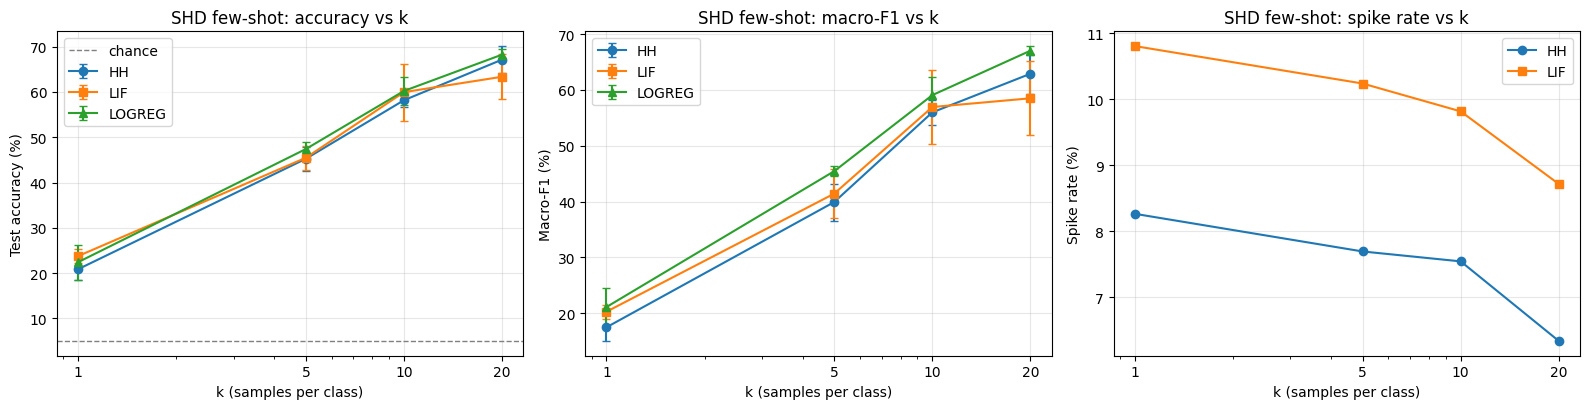

In [17]:
ks = sorted(agg.k_shot.unique())
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# 13a. accuracy vs k, mean +- std
for nt, marker in [('hh', 'o'), ('lif', 's'), ('logreg', '^')]:
    sub = agg[agg.neuron_type == nt].sort_values('k_shot')
    if sub.empty: continue
    axes[0].errorbar(sub.k_shot, sub.acc_mean, yerr=sub.acc_std.fillna(0),
                     marker=marker, capsize=3, label=nt.upper())
axes[0].axhline(100 / NUM_CLASSES, ls='--', c='gray', lw=1, label='chance')
axes[0].set_xlabel('k (samples per class)'); axes[0].set_ylabel('Test accuracy (%)')
axes[0].set_title('SHD few-shot: accuracy vs k'); axes[0].set_xscale('log')
axes[0].set_xticks(ks); axes[0].set_xticklabels(ks)
axes[0].legend(); axes[0].grid(alpha=0.3)

# 13b. macro-F1 vs k
for nt, marker in [('hh', 'o'), ('lif', 's'), ('logreg', '^')]:
    sub = agg[agg.neuron_type == nt].sort_values('k_shot')
    if sub.empty: continue
    axes[1].errorbar(sub.k_shot, sub.f1_mean, yerr=sub.f1_std.fillna(0),
                     marker=marker, capsize=3, label=nt.upper())
axes[1].set_xlabel('k (samples per class)'); axes[1].set_ylabel('Macro-F1 (%)')
axes[1].set_title('SHD few-shot: macro-F1 vs k'); axes[1].set_xscale('log')
axes[1].set_xticks(ks); axes[1].set_xticklabels(ks)
axes[1].legend(); axes[1].grid(alpha=0.3)

# 13c. spike rate vs k
for nt, marker in [('hh', 'o'), ('lif', 's')]:
    sub = agg[agg.neuron_type == nt].sort_values('k_shot')
    if sub.empty: continue
    axes[2].plot(sub.k_shot, sub.rate * 100, marker=marker, label=nt.upper())
axes[2].set_xlabel('k (samples per class)'); axes[2].set_ylabel('Spike rate (%)')
axes[2].set_title('SHD few-shot: spike rate vs k'); axes[2].set_xscale('log')
axes[2].set_xticks(ks); axes[2].set_xticklabels(ks)
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/shd_fewshot_plots.png', dpi=150, bbox_inches='tight')
plt.show()


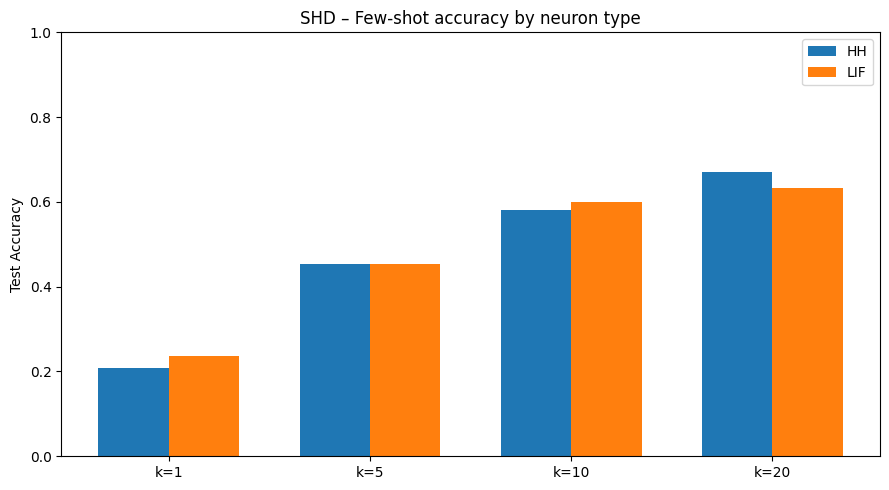

In [20]:
# ── grouped bar chart: HH vs LIF accuracy by k ────────────────────────────
ks = sorted(agg.k_shot.unique())
x = np.arange(len(ks))
width = 0.35

hh_acc  = [agg[(agg.neuron_type == 'hh')  & (agg.k_shot == k)].acc_mean.values[0] / 100 for k in ks]
lif_acc = [agg[(agg.neuron_type == 'lif') & (agg.k_shot == k)].acc_mean.values[0] / 100 for k in ks]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, hh_acc,  width, label='HH',  color='tab:blue')
ax.bar(x + width/2, lif_acc, width, label='LIF', color='tab:orange')

ax.set_xticks(x)
ax.set_xticklabels([f'k={k}' for k in ks])
ax.set_ylim(0, 1.0)
ax.set_ylabel('Test Accuracy')
ax.set_title('SHD – Few-shot accuracy by neuron type')
ax.legend()

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/shd_fewshot_barchart.png', dpi=150, bbox_inches='tight')
plt.show()

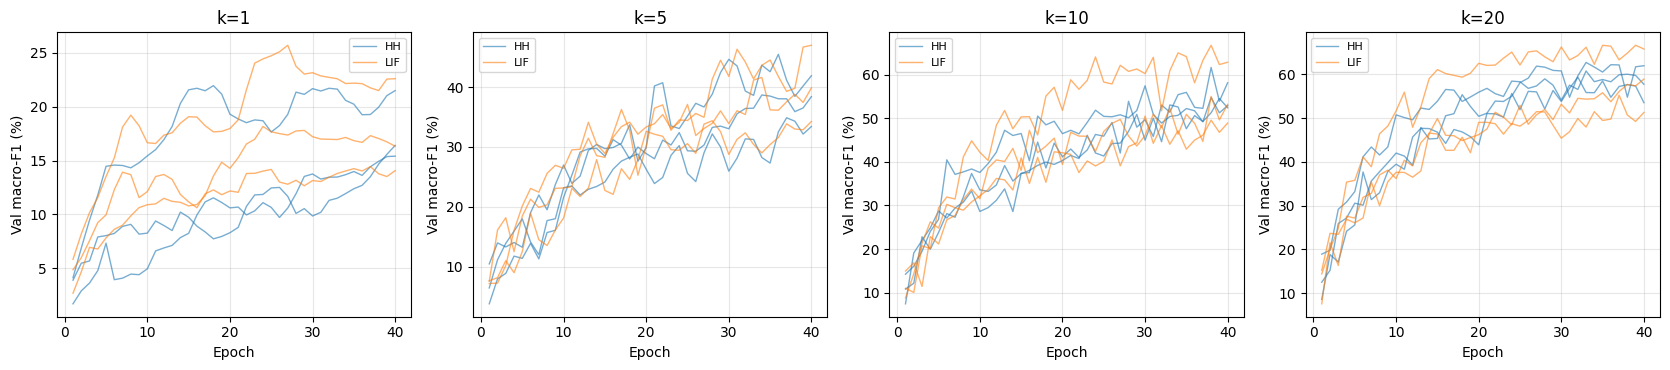

In [18]:
# ── validation curves, one panel per k ────────────────────────────────────
ks_plot = [k for k in ks if k in set(raw.k_shot)]
fig, axes = plt.subplots(1, len(ks_plot), figsize=(4.2 * len(ks_plot), 3.8), squeeze=False)
for j, k in enumerate(ks_plot):
    ax = axes[0][j]
    for nt, c in [('hh', 'tab:blue'), ('lif', 'tab:orange')]:
        sub = raw[(raw.k_shot == k) & (raw.neuron_type == nt)]
        for _, r in sub.iterrows():
            if not r['val_f1s']: continue
            ax.plot(range(1, len(r['val_f1s']) + 1), np.array(r['val_f1s']) * 100,
                    c=c, alpha=0.6, lw=1,
                    label=nt.upper() if _ == sub.index[0] else None)
    ax.set_title(f'k={k}'); ax.set_xlabel('Epoch'); ax.set_ylabel('Val macro-F1 (%)')
    ax.grid(alpha=0.3)
    h, l = ax.get_legend_handles_labels()
    if l: ax.legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys(), fontsize=8)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/shd_fewshot_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 14. Final summary table

In [19]:
print('=' * 88)
print(f"{'Model':>14} | {'k':>5} | {'n_train':>8} | {'Acc %':>14} | "
      f"{'F1 %':>14} | {'SpikeRate':>10}")
print('=' * 88)
for _, r in agg.iterrows():
    astd = 0.0 if pd.isna(r.acc_std) else r.acc_std
    fstd = 0.0 if pd.isna(r.f1_std) else r.f1_std
    print(f"{r.neuron_type.upper():>14} | {int(r.k_shot):>5} | {int(r.n_train):>8} | "
          f"{r.acc_mean:>7.2f} ± {astd:>4.2f} | {r.f1_mean:>7.2f} ± {fstd:>4.2f} | "
          f"{r.rate:>10.5f}")
print('=' * 88)
print(f'chance accuracy = {100/NUM_CLASSES:.1f}%  |  seeds per cell = {N_REPEATS}')


         Model |     k |  n_train |          Acc % |           F1 % |  SpikeRate
            HH |     1 |       20 |   20.85 ± 2.39 |   17.48 ± 2.45 |    0.08263
           LIF |     1 |       20 |   23.75 ± 1.50 |   20.27 ± 1.24 |    0.10808
        LOGREG |     1 |       20 |   22.41 ± 3.87 |   21.11 ± 3.33 |    0.00000
            HH |     5 |      100 |   45.24 ± 2.66 |   39.92 ± 3.31 |    0.07692
           LIF |     5 |      100 |   45.47 ± 2.64 |   41.42 ± 4.40 |    0.10239
        LOGREG |     5 |      100 |   47.39 ± 1.54 |   45.44 ± 0.89 |    0.00000
            HH |    10 |      200 |   58.17 ± 1.59 |   55.98 ± 2.22 |    0.07541
           LIF |    10 |      200 |   59.95 ± 6.28 |   56.93 ± 6.63 |    0.09817
        LOGREG |    10 |      200 |   60.22 ± 3.07 |   59.06 ± 3.27 |    0.00000
            HH |    20 |      400 |   67.14 ± 2.99 |   62.89 ± 3.62 |    0.06334
           LIF |    20 |      400 |   63.35 ± 4.97 |   58.49 ± 6.60 |    0.08715
        LOGREG |    20 |    

## Notes

- **Test set is never subsampled.** All k values are evaluated on the full
  official SHD test split (disjoint speakers), so accuracy is comparable across
  the whole k grid and against the full-data SHD result.
- **Speaker-level split comes before few-shot sampling**, so a k-shot support
  set can never share a speaker with the validation set. Doing it the other way
  round inflates every few-shot number.
- **`N_REPEATS` matters most at k=1.** With 20 training samples total, the draw
  dominates: report mean ± std, and treat a single-seed HH-vs-LIF gap at k=1 as
  noise unless `hh_wins_acc` in the paired table is consistent.
- **Soft targets and `tau_ref=0.15` are load-bearing**, not cosmetic. Hard
  one-hot targets at C=20 freeze output rows once `f(z_c)=0`, which shows up as
  a macro-F1 collapse while accuracy looks survivable — hence F1 as the
  checkpoint monitor.
- **Augmentation is on by default.** At k=1 it is doing a lot of work; if the
  paper claim is about raw sample efficiency rather than the full pipeline,
  re-run with `AUGMENT = False` and report both.
- The logistic-regression baseline uses the identical index sets, so any
  HH-PC advantage at low k is attributable to the model rather than to the draw.
